In [2]:
import pandas as pd
import seaborn as sns

In [3]:
df=pd.read_csv("placement.csv")

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df=df.iloc[:,1:]

In [6]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


<Axes: xlabel='cgpa', ylabel='iq'>

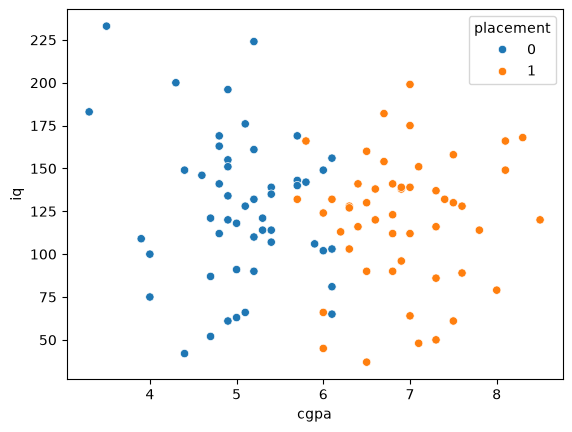

In [7]:
sns.scatterplot(data=df,x='cgpa',y='iq',hue='placement')

In [8]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [9]:
x.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [10]:
y.head()

0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int64

In [11]:
from sklearn.model_selection import  train_test_split

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [13]:
x_train

,cgpa,iq
58,8.0,79.0
0,6.8,123.0
13,6.4,116.0
23,4.7,87.0
4,5.8,142.0
...,...,...
40,4.9,134.0
97,6.7,182.0
3,7.4,132.0
43,6.8,141.0


In [14]:
x_test

,cgpa,iq
55,7.8,114.0
57,6.5,130.0
78,6.1,81.0
50,3.5,233.0
17,3.3,183.0
75,4.8,169.0
41,5.4,114.0
19,5.2,132.0
22,4.9,120.0
28,5.2,90.0


In [15]:
y_test

55    1
57    1
78    0
50    0
17    0
75    0
41    0
19    0
22    0
28    0
Name: placement, dtype: int64

In [16]:
y_train

58    1
0     1
13    1
23    0
4     0
     ..
40    0
97    1
3     1
43    1
37    1
Name: placement, Length: 90, dtype: int64

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler=StandardScaler()

In [19]:
x_train=scaler.fit_transform(x_train)

In [20]:
x_train

array([[ 1.76323727, -1.10572284],
       [ 0.66629243,  0.022217  ],
       [ 0.30064414, -0.15722798],
       [-1.25336106, -0.90064287],
       [-0.24782828,  0.50928193],
       [-0.88771277,  0.15039198],
       [-0.33924035,  0.25293196],
       [ 0.84911657, -1.49024779],
       [ 0.84911657,  1.97047672],
       [-0.33924035,  0.45801193],
       [ 0.7577045 ,  0.40674194],
       [ 0.20923207, -0.49048293],
       [ 0.20923207,  0.12475698],
       [-0.06500414,  0.6887269 ],
       [-0.70488863, -0.20849797],
       [ 0.57488035,  0.81690188],
       [-1.07053692,  1.89357173],
       [ 1.30617692,  0.91944187],
       [ 0.7577045 ,  0.43237694],
       [-0.7963007 ,  0.99634686],
       [-0.24782828,  1.12452184],
       [ 0.84911657,  1.35523681],
       [ 1.39758899,  0.15039198],
       [-0.7963007 , -0.31103796],
       [-0.06500414, -1.4389778 ],
       [-1.16194899, -0.25976796],
       [-0.88771277,  1.3808718 ],
       [-0.15641621, -0.41357794],
       [ 0.7577045 ,

In [21]:
x_test=scaler.transform(x_test)

In [22]:
x_test

array([[ 1.58041313, -0.20849797],
       [ 0.39205621,  0.20166197],
       [ 0.02640793, -1.05445285],
       [-2.3503059 ,  2.8420666 ],
       [-2.53313004,  1.56031678],
       [-1.16194899,  1.20142683],
       [-0.61347656, -0.20849797],
       [-0.7963007 ,  0.25293196],
       [-1.07053692, -0.05468799],
       [-0.7963007 , -0.82373788]])

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
clf=LogisticRegression()

In [25]:
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [30]:
y_pred=clf.predict(x_test)

In [27]:
y_test

55    1
57    1
78    0
50    0
17    0
75    0
41    0
19    0
22    0
28    0
Name: placement, dtype: int64

In [28]:
from sklearn.metrics import accuracy_score

In [31]:
accuracy_score(y_test,y_pred)

0.9

In [32]:
import pickle

In [33]:
pickle.dump(clf,open("model.pkl","wb"))